In [182]:
import app
import datetime
import json
import os.path

import pandas as pd
import requests

import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import seaborn as sns

Import data

In [183]:
ecoli_timeseries_dfs = app.get_ecoli_datasets()

Plot e-coli time series

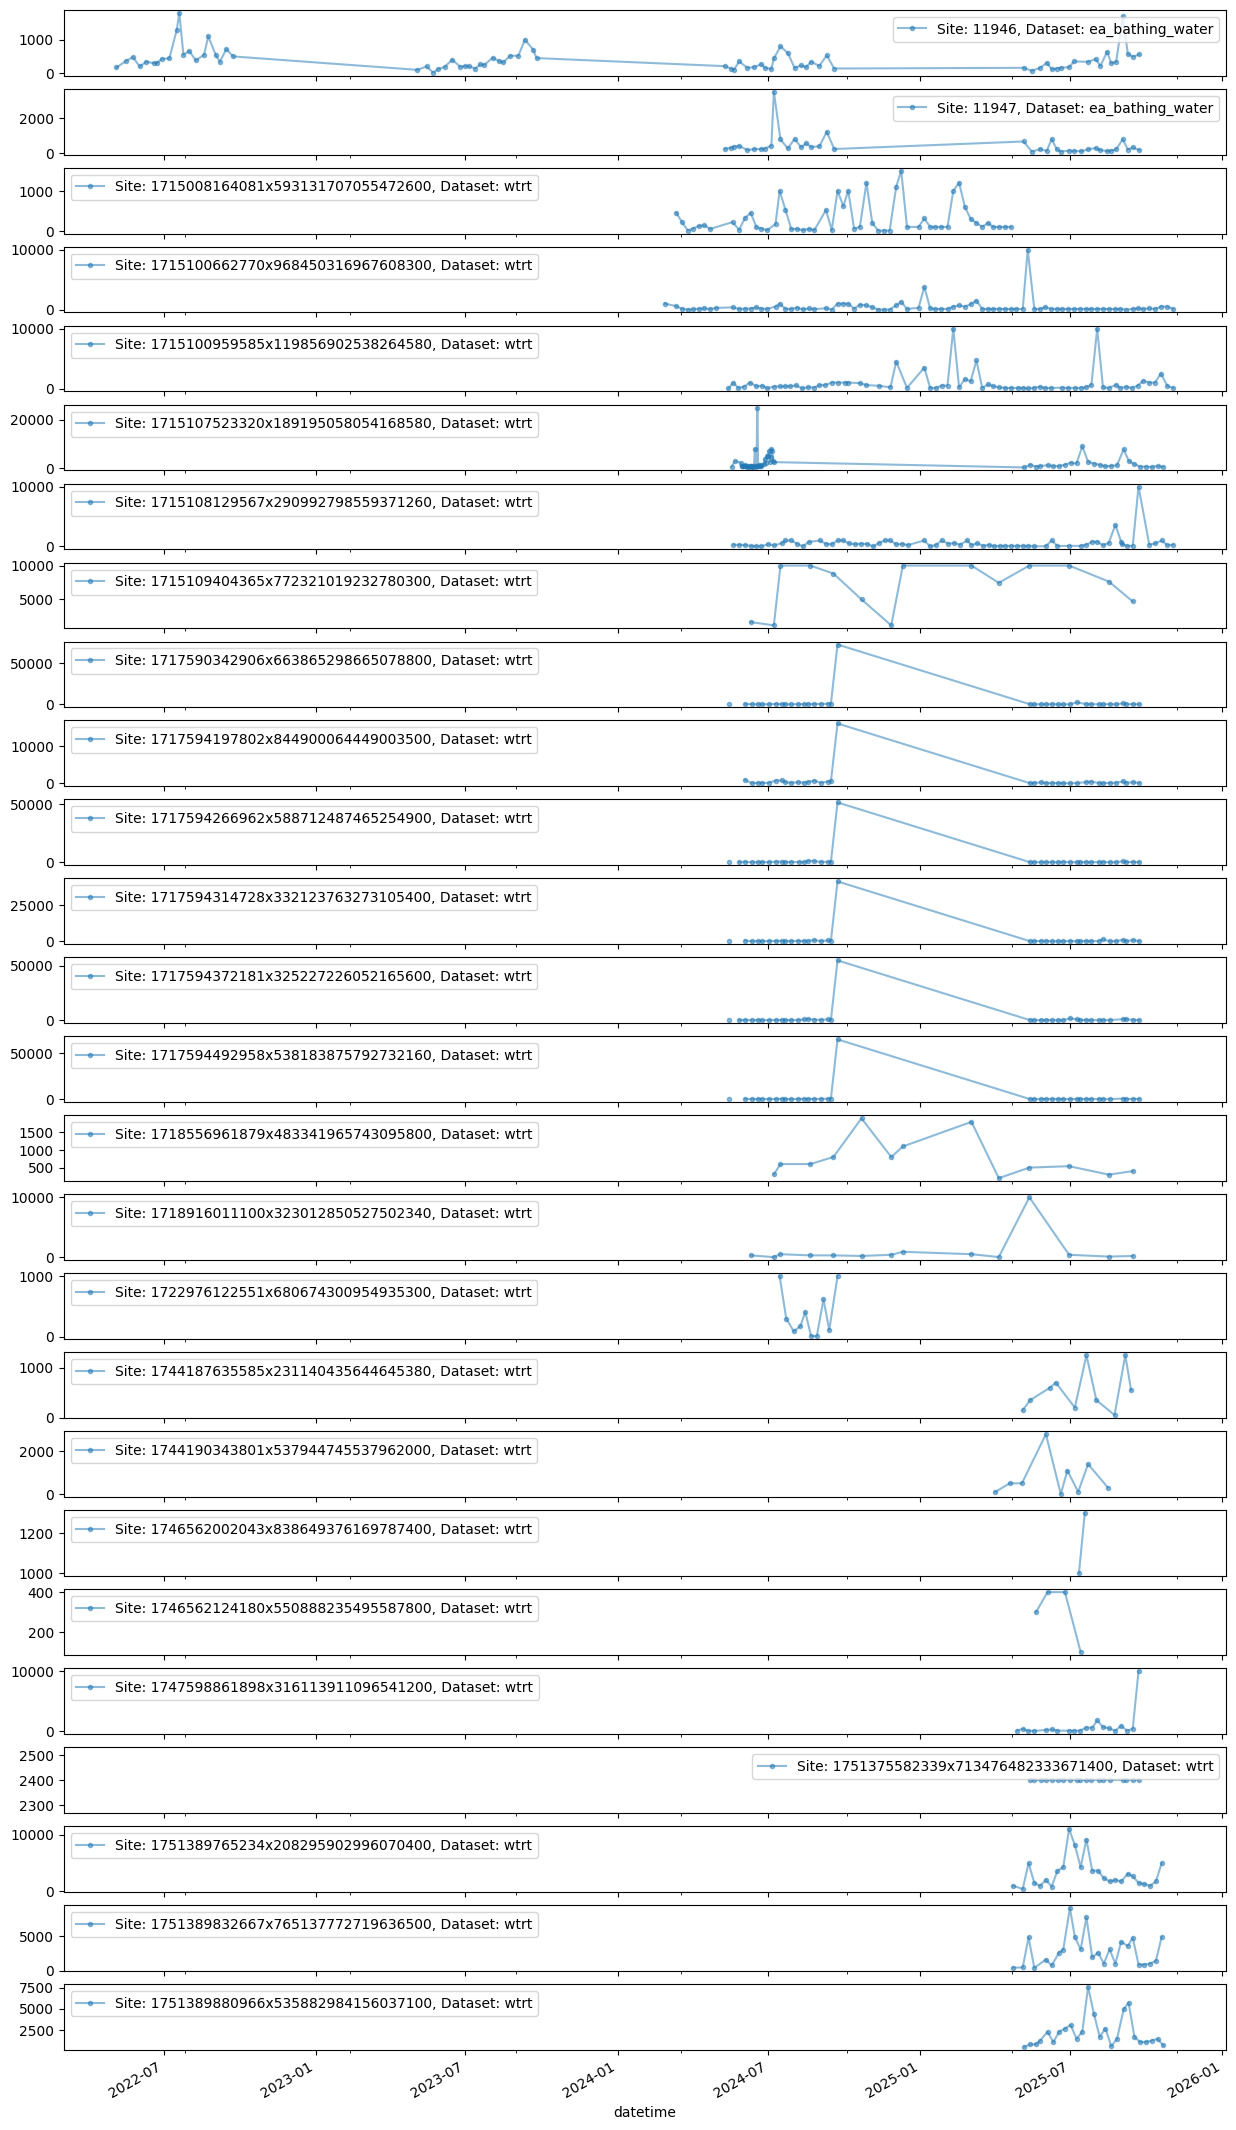

In [184]:
no_dfs = len(ecoli_timeseries_dfs)

fig, ax = plt.subplots(no_dfs, figsize=(15, 30), sharex=True)

#properly align dates, fill missing dates with NaN, deal with multiple measurements in a day
dates_complete = pd.date_range(start='2021-01-01', end='2025-11-01', freq='D')

for i, (df, key) in enumerate(zip(ecoli_timeseries_dfs.values(), ecoli_timeseries_dfs.keys())):
    df['datetime'] = df['datetime'].dt.floor('D') # Keep date only, ignore time of measurement
    df = df.groupby('datetime').first().reset_index() #in case of multiple measurements in a day, take first
    #df = df.set_index('datetime').reindex(dates_complete).reset_index().rename(columns={'index': 'datetime'})
    df.plot(x='datetime', y='escherichia coli count', ax=ax[i], alpha=0.5, label = f'Site: {key[0]}, Dataset: {key[1]}', style='.-')
    ax[i].legend()

Get predictors for a given target site

Wolvercote Mill Stream, Wallingford Beach, Jubilee River, Marsh Lane (Laboratory testing), Boulters Lock (Laboratory testing), Riversdale, Bourne End (Laboratory testing), Windsor, Alexandra Park (Laboratory testing)

In [185]:
all_datasets = ['ea_bathing_water','edm', 'rainfall', 'fft', 'ea_water_quality', 'ea_lf_sonde', 'ea_wq_sonde', 'wtrt'] #ea_flood_warnings doesn't have timeseries data, freshwater_watch as data is v messy
predictor_datasets = [ds for ds in all_datasets if ds != 'ea_bathing_water'] #don't include bathing water data as predictor #ds != target_dataset and
determinand_datasets = ['ea_water_quality', 'ea_wq_sonde', 'ea_lf_sonde'] #datasets that require determinands
date_datasets = ['edm']

keep_datasets = ['rainfall','ea_lf_sonde'] # only keep best predictor datasets 

sites_dfs = {}

#extract all site details and convert to GeoDataFrames
for dataset_name in all_datasets:
    df = app.get_sites_for_dataset_as_pandas(dataset_name, display=False)
    df = gpd.GeoDataFrame(df)
    df['geometry.coordinates'] = gpd.points_from_xy(pd.DataFrame(df["geometry.coordinates"].to_list())[0], pd.DataFrame(df["geometry.coordinates"].to_list())[1])
    df.set_geometry('geometry.coordinates', inplace=True)
    sites_dfs[dataset_name] = df

In [186]:
def target_and_nearby_sites(target_dataset, sites_dfs, target_name, max_distance, no_keep):

    #extract details about target dataset
    target_location = sites_dfs[target_dataset][sites_dfs[target_dataset]["properties.name"] == target_name]["geometry.coordinates"]
    target_id = sites_dfs[target_dataset][sites_dfs[target_dataset]["properties.name"] == target_name]["properties.id"].values[0]
    target_ecoli = ecoli_timeseries_dfs[(target_id, target_dataset)].set_index('datetime')

    complete_target_dates = pd.date_range(start=target_ecoli['escherichia coli count'].index.min(), end=target_ecoli['escherichia coli count'].index.max(), freq='D')
    df_target = pd.DataFrame(index = complete_target_dates)
    df_target = pd.concat([df_target, target_ecoli['escherichia coli count']], axis = 1) #extract e-coli as target variable
    df_target['datetime'] = df_target.index
    df_target['datetime'] = df_target['datetime'].dt.tz_localize(None) #remove timezone info for merging
    df_target = df_target.rename(columns={'escherichia coli count': 'target_ecoli'}).set_index('datetime')
    
    #set max ecoli value to 1000
    df_target['target_ecoli'] = df_target['target_ecoli'].clip(upper=1000)

    #create lagged target variable with max gap of 30 days

    s = df_target['target_ecoli'].sort_index().dropna()
    s_lag = s.shift(1)

    time_diff = s.index.to_series().diff()  # timedeltas

    # mask lags where the gap > 14 days
    lagged_ecoli = s_lag.where(time_diff <= pd.Timedelta(days=14)).rename('lagged_ecoli')

    df_lagged_ecoli = pd.DataFrame(lagged_ecoli)

    # find sites near target location
    nearby_dfs = {}

    for dataset_name in predictor_datasets:
        df = sites_dfs[dataset_name]
        df['distance_to_target'] = df['geometry.coordinates'].distance(target_location.values[0])
        nearby_sites = df[df['distance_to_target'] < max_distance].copy()
        nearby_sites_sort = nearby_sites.sort_values(by='distance_to_target')
        nearby_dfs[dataset_name] = nearby_sites_sort[0:no_keep] #keep only no_keep closest sites to reduce amount of data

    return df_target, df_lagged_ecoli, nearby_dfs

In [187]:
""" #CHANGE SITES TO SELECT HERE
max_distance = 0.075 # e.g., within 0.075 degrees (~8 km)
no_keep = 3 #number of nearby sites to keep for each dataset

#CHANGE TO DESIRED TARGET SITE HERE
target_dataset = 'wtrt' #wtrt or ea_bathing_water
target_name = 'Riversdale, Bourne End (Laboratory testing)' #e.g. 'Boulters Lock (Laboratory testing)' or 'Wolvercote Mill Stream' """

" #CHANGE SITES TO SELECT HERE\nmax_distance = 0.075 # e.g., within 0.075 degrees (~8 km)\nno_keep = 3 #number of nearby sites to keep for each dataset\n\n#CHANGE TO DESIRED TARGET SITE HERE\ntarget_dataset = 'wtrt' #wtrt or ea_bathing_water\ntarget_name = 'Riversdale, Bourne End (Laboratory testing)' #e.g. 'Boulters Lock (Laboratory testing)' or 'Wolvercote Mill Stream' "

In [188]:
target_names = ['Wolvercote Mill Stream', 'Jubilee River, Marsh Lane (Laboratory testing)', 'Boulters Lock (Laboratory testing)', 'Riversdale, Bourne End (Laboratory testing)', 'Windsor, Alexandra Park (Laboratory testing)']
target_datasets = ['ea_bathing_water', 'wtrt', 'wtrt', 'wtrt', 'wtrt']
names_short = ['Wolvercote', 'Jubilee_River', 'Boulters_Lock', 'Riversdale', 'Windsor']

In [189]:
target_dfs = {}
lagged_ecoli_dfs = {}
nearby_dfs_all = {}

max_distance = 0.075 # e.g., within 0.075 degrees (~8 km)
no_keep = 2 #number of nearby sites to keep for each dataset

for target_dataset, target_name, short in zip(target_datasets, target_names, names_short):
    target_dfs[short], lagged_ecoli_dfs[short], nearby_dfs_all[short] = target_and_nearby_sites(target_dataset, sites_dfs, target_name, max_distance, no_keep)

In [190]:
data_to_keep = ['rainfall','ea_lf_sonde'] # only keep best predictor datasets

nearby_dfs = {}

for data in data_to_keep:
    nearby_dfs[data] = pd.DataFrame()
    for site in nearby_dfs_all.keys():
        nearby_dfs[data] = pd.concat([nearby_dfs[data], nearby_dfs_all[site][data]])
    nearby_dfs[data] = nearby_dfs[data].drop_duplicates(subset=['properties.id'])

In [191]:
# extract timeseries data for nearby sites

timeseries_dfs = {}

for dataset_name in data_to_keep:
    df_sites = nearby_dfs[dataset_name]

    if dataset_name =='wtrt' and dataset_name in keep_datasets: #special case for wtrt dataset
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            if row['properties.name'] == target_name:
                continue
            else:
                try:
                    site_name = row['properties.name']
                    df_site = ecoli_timeseries_dfs[(row['properties.id'], dataset_name)]
                    df_site['datetime'] = pd.to_datetime(df_site['datetime']).dt.floor('D')
                    df_site['datetime'] = df_site['datetime'].dt.tz_localize(None) #remove timezone info for merging
                    df_site = df_site.set_index('datetime')['escherichia coli count'].to_frame() #note this drops the > = < column
                    df_site = df_site.rename(columns={'escherichia coli count': f'{dataset_name}_{site_name}'})
                    timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)
                except Exception as e:
                    print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")

    elif dataset_name not in determinand_datasets and dataset_name not in date_datasets and dataset_name in keep_datasets: #i.e. datasets that do not require determinand IDs or date to extract timeseries
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            try:
                site_name = row['properties.id']
                df_site = app.get_timeseries_for_dataset_and_site_as_pandas(site_name, dataset_name, display=False)
                df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                df_site = df_site.sort_values('datetime').reset_index(drop=True)
                
                if dataset_name == 'fft':
                    df_site['datetime'] = df_site['datetime'].dt.floor('D') # Get average per day
                    df_site = df_site.groupby('datetime').mean().reset_index()

                df_site = df_site.rename(columns={'value': f'{dataset_name}_{site_name}'})
                df_site = df_site.set_index('datetime')
                timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)
            except Exception as e:
                print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")

    elif dataset_name in date_datasets and dataset_name in keep_datasets: #i.e. datasets that require date to extract timeseries (i.e. edm)
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            try:
                site_name = row['properties.id']
                date = datetime.date(2021, 1, 1)
                df_site = app.get_timeseries_for_date_dataset_as_pandas(site_name, dataset_name, date, display=False)

                df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                df_site = df_site.sort_values('datetime').reset_index(drop=True)
                df_site = app.process_edm(df_site)
                df_site = df_site.rename(columns={'duration_hours': f'{dataset_name}_{site_name}'})
                df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                df_site = df_site.set_index('datetime')
                timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)
            except Exception as e:
                print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")

    elif dataset_name in determinand_datasets and dataset_name in keep_datasets: #i.e. datasets that require determinand IDs to extract timeseries
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            try:
                site_name = row['properties.id']
                if dataset_name == 'ea_lf_sonde':
                    determinands = row['properties.measures']
                    determinands = [determinands[i][0] for i in range(len(determinands))]
                elif dataset_name == 'ea_wq_sonde':
                    determinands = row['properties.measures']
                    determinands = [determinands[i][0] for i in range(len(determinands))]
                elif dataset_name == 'ea_water_quality':
                    determinands = row['properties.determinand_ids']
                else:
                    print(f"Dataset {dataset_name} not recognised for determinand extraction.")
                for determinand in determinands:
                    df_site = app.get_timeseries_for_dataset_site_determinand_as_pandas(site_name, dataset_name, determinand, display=False)

                    df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                    df_site = df_site.sort_values('datetime').reset_index(drop=True)
                    df_site = df_site.rename(columns={'value': f'{dataset_name}_{site_name}_{determinand}'})
                    df_site['datetime'] = df_site['datetime'].dt.floor('D') # Get average per day
                    df_site = df_site.groupby('datetime').mean().reset_index()
                    df_site = df_site.set_index('datetime')
                    timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)

            except Exception as e:
                print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")
        #df_site = app.get_timeseries_for_dataset_site_determinand_as_pandas("E01612A", "ea_wq_sonde", "turbidity", display=False)
        continue


In [192]:
#bring all time series into a common dataframe

df_predictors = pd.DataFrame(index = dates_complete)

for dataset_name, df in timeseries_dfs.items():
    df_predictors = pd.concat([df_predictors, df], axis=1)

""" if target_dataset == 'ea_bathing_water': #wtrt doesn't have enterococci data
    enterococci_predictor = target_ecoli['intestinal enterococci count'] #extract enterococci as predictor variable to add to other predictors
    df_predictors = pd.concat([df_predictors, enterococci_predictor], axis=1) """

" if target_dataset == 'ea_bathing_water': #wtrt doesn't have enterococci data\n    enterococci_predictor = target_ecoli['intestinal enterococci count'] #extract enterococci as predictor variable to add to other predictors\n    df_predictors = pd.concat([df_predictors, enterococci_predictor], axis=1) "

In [193]:
for col in df_predictors.columns:
    #rolling weekly average
    df_predictors[f'{col}_7day_avg'] = df_predictors[col].rolling(window=7).mean()
    df_predictors[f'{col}_3day_avg'] = df_predictors[col].rolling(window=3).mean()
    df_predictors[f'{col}_1_lag'] = df_predictors[col].shift(1)
    df_predictors[f'{col}_2_lag'] = df_predictors[col].shift(2)
    df_predictors[f'{col}_3_lag'] = df_predictors[col].shift(3)

    #yesterday's value
    #df_predictors[f'{col}_lag_1'] = df_predictors[col].shift(1)

df_predictors['DoY'] = df_predictors.index.dayofyear
df_predictors['month'] = df_predictors.index.month

(18628.0, 20412.0)

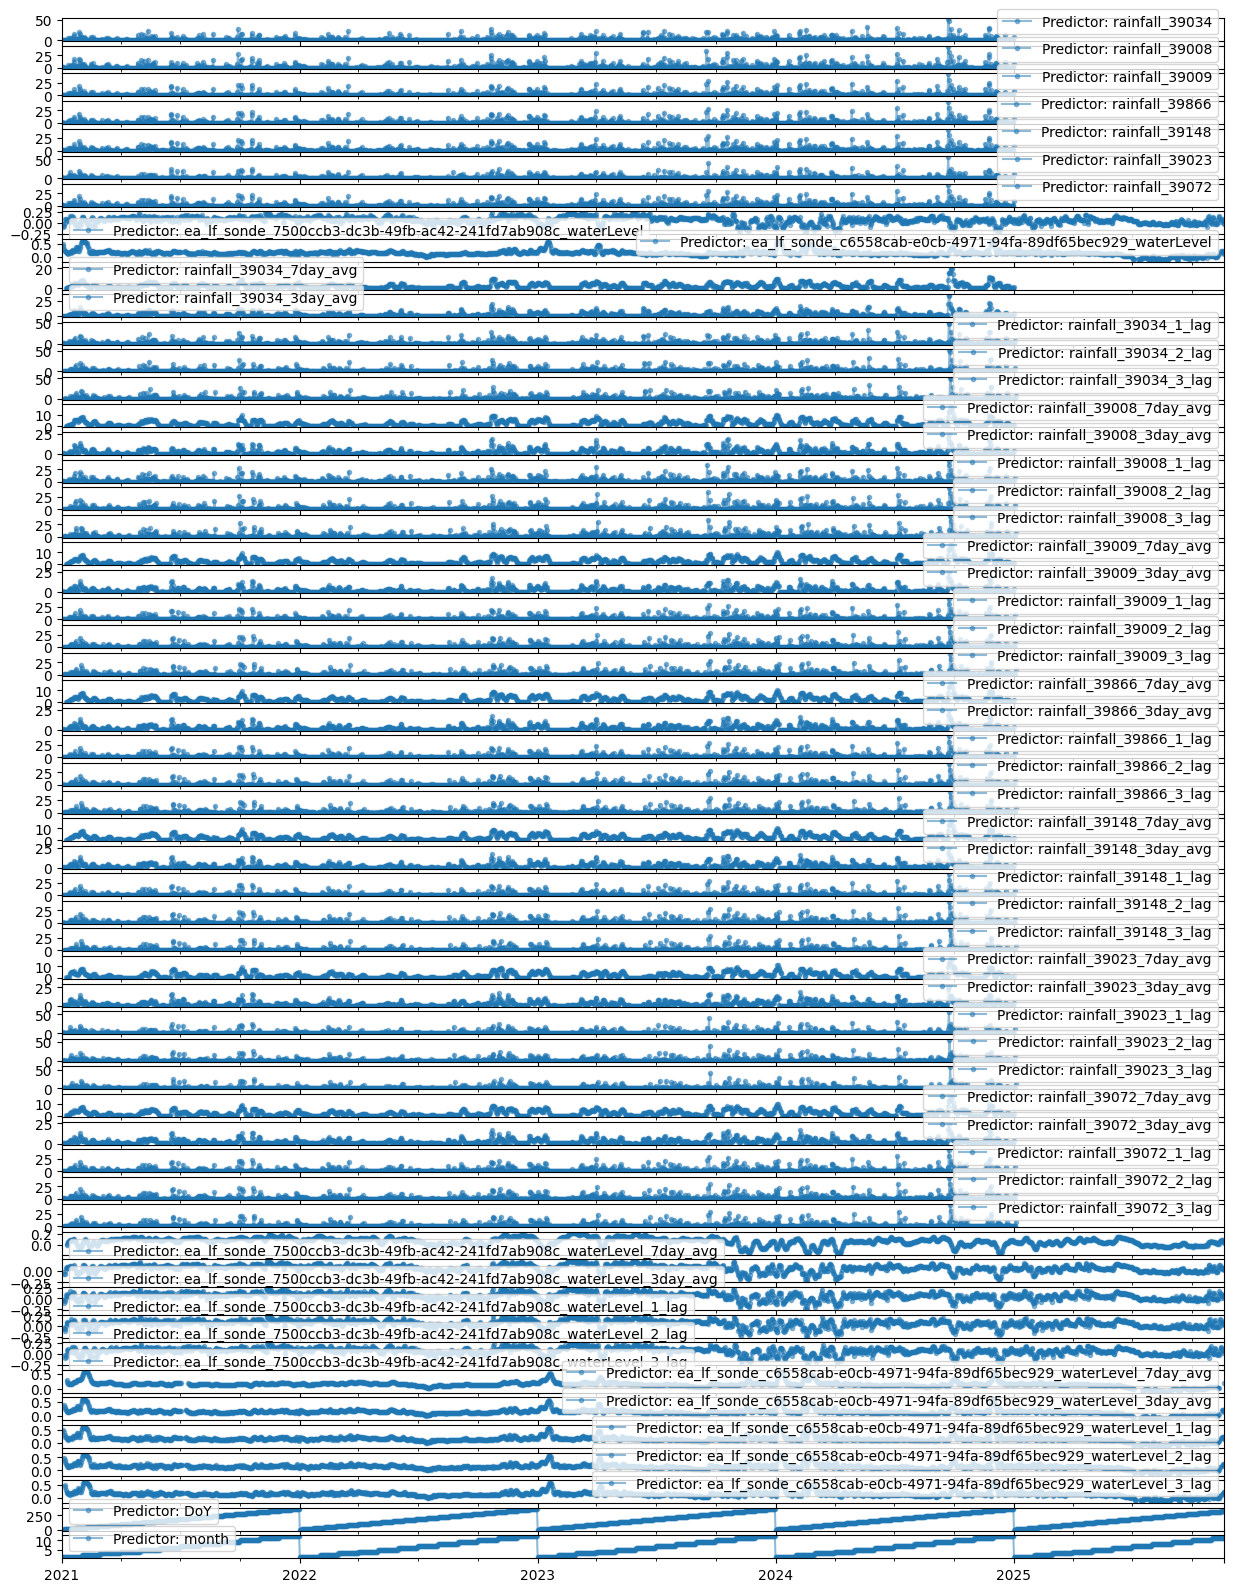

In [194]:
no_predictors = len(df_predictors.columns)
fig, ax = plt.subplots(no_predictors, figsize=(15, 20), sharex = True)

for i, column in enumerate(df_predictors.columns):
    df_predictors[column].plot(ax=ax[i], alpha = 0.5, label = f'Predictor: {column}', style='.-')
    ax[i].legend()

#ax[0].set_xlim(datetime.date(2023, 5, 1), datetime.date(2023, 10, 1))
ax[0].set_xlim(df_predictors.index.min(), df_predictors.index.max())

Add other predictor columns

In [195]:
target_predictors_dfs = {}

for site in target_dfs.keys():
    target_predictors_dfs[site] = pd.concat([target_dfs[site], lagged_ecoli_dfs[site], df_predictors], axis=1).dropna()
    target_predictors_dfs[site]['name'] = site
    target_predictors_dfs[site] = target_predictors_dfs[site].reset_index().drop(columns = 'index')

In [196]:
df_target_predictors = pd.DataFrame()

for site in target_predictors_dfs.keys():
    df_target_predictors = pd.concat([df_target_predictors, target_predictors_dfs[site]], ignore_index=True)

In [197]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False)
enc.fit(df_target_predictors[['name']])
encoded_names = enc.transform(df_target_predictors[['name']])
encoded_df = pd.DataFrame(encoded_names, columns=enc.get_feature_names_out(['name']))
name_column = df_target_predictors['name']
df_target_predictors = pd.concat([df_target_predictors.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1).drop(columns=['name'])

In [198]:
df_target_predictors

,target_ecoli,lagged_ecoli,rainfall_39034,rainfall_39008,rainfall_39009,rainfall_39866,rainfall_39148,rainfall_39023,rainfall_39072,ea_lf_sonde_7500ccb3-dc3b-49fb-ac42-241fd7ab908c_waterLevel,...,ea_lf_sonde_c6558cab-e0cb-4971-94fa-89df65bec929_waterLevel_1_lag,ea_lf_sonde_c6558cab-e0cb-4971-94fa-89df65bec929_waterLevel_2_lag,ea_lf_sonde_c6558cab-e0cb-4971-94fa-89df65bec929_waterLevel_3_lag,DoY,month,name_Boulters_Lock,name_Jubilee_River,name_Riversdale,name_Windsor,name_Wolvercote
0,370.0,170.0,3.428,2.649,2.059,2.059,2.059,0.994,2.032,0.195439,...,0.196704,0.135735,0.131755,137,5,0.0,0.0,0.0,0.0,1.0
1,480.0,370.0,0.207,0.170,0.397,0.397,0.397,0.245,0.408,0.059763,...,0.187111,0.208474,0.216404,145,5,0.0,0.0,0.0,0.0,1.0
2,200.0,480.0,0.000,0.001,0.006,0.006,0.006,0.000,0.005,0.095235,...,0.156670,0.157673,0.151596,153,6,0.0,0.0,0.0,0.0,1.0
3,340.0,200.0,0.004,0.015,0.005,0.005,0.005,0.000,0.005,0.072469,...,0.168122,0.209469,0.209536,161,6,0.0,0.0,0.0,0.0,1.0
4,300.0,340.0,0.112,0.534,1.092,1.093,1.092,0.736,1.073,0.131030,...,0.136717,0.113704,0.143837,170,6,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,1000.0,580.0,6.802,4.230,4.267,4.268,4.268,4.712,4.228,0.081173,...,0.153031,0.156701,0.129677,324,11,0.0,0.0,0.0,1.0,0.0
181,1000.0,1000.0,9.618,6.709,10.523,10.518,10.520,13.793,10.749,0.064619,...,0.366247,0.125556,0.092837,331,11,0.0,0.0,0.0,1.0,0.0
182,350.0,1000.0,0.110,0.068,0.077,0.077,0.077,0.035,0.078,-0.159041,...,0.448306,0.525980,0.581041,338,12,0.0,0.0,0.0,1.0,0.0
183,430.0,350.0,0.000,0.003,0.011,0.011,0.011,0.000,0.011,-0.182143,...,0.295898,0.274827,0.221735,345,12,0.0,0.0,0.0,1.0,0.0


In [199]:
X = df_target_predictors.drop(columns=['target_ecoli'])
y = df_target_predictors['target_ecoli']

## Random forest prediction

Initial baseline

In [200]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,max_error,explained_variance_score,r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Mean Absolute Error, MAE = %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error, MSE = %.2f" % mean_squared_error(y_test, y_pred))
print("Max Error = %.2f" % max_error(y_test, y_pred))
print("Explained Variance Score = %.2f" % explained_variance_score(y_test, y_pred))
print("Coefficient of determination, r2 = %.2f" % r2_score(y_test, y_pred)) #usually use this one

Mean Absolute Error, MAE = 176.19
Mean squared error, MSE = 56991.61
Max Error = 732.52
Explained Variance Score = 0.46
Coefficient of determination, r2 = 0.45


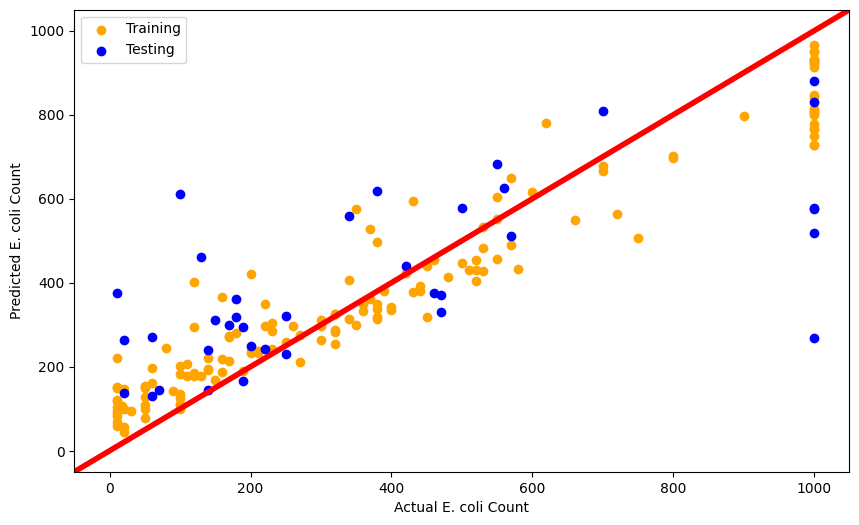

In [201]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_train, rf.predict(X_train), color = 'orange')
ax.scatter(y_test, y_pred, color = 'blue')
ax.set_xlabel('Actual E. coli Count')
ax.set_ylabel('Predicted E. coli Count')

ax.legend(['Training', 'Testing', 'Predicted'])

ax.axline((0, 0), (1000, 1000), linewidth=4, color='r')

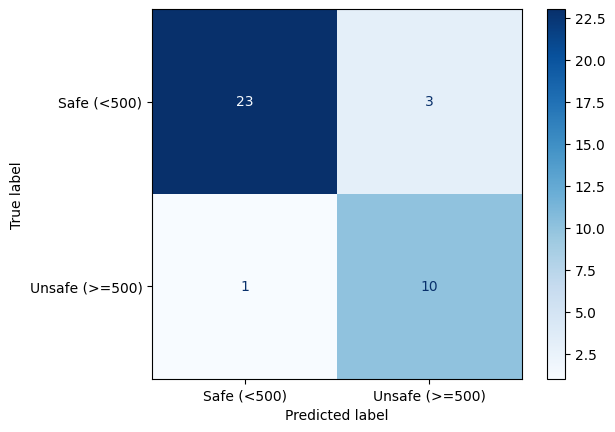

In [202]:
# use 500 threshold = excellent to get confusion matrix
# EC: ≤500 cfu/100ml


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_class = (y_test >= 500).astype(int)
y_pred_class = (y_pred >= 500).astype(int)

cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (<500)', 'Unsafe (>=500)'])
disp.plot(cmap=plt.cm.Blues)

## Cross Validation and Hyperparameter Tuning

Use LeaveOneGroupOut cross validation to test on each site and train on the other 4 sites, in sequence

In [203]:
""" from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, name_column,
    test_size=0.2,
    random_state=42,
    stratify=name_column
)

logo = LeaveOneGroupOut()

cv = logo.split(X_train, y_train, groups=groups_train)

r2_scores = []

for train_idx, test_idx in cv:
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_fold, y_train_fold)
    y_pred_fold = rf.predict(X_test_fold)
    
    r2_scores.append(r2_score(y_test_fold, y_pred_fold))

print(r2_scores, np.mean(r2_scores)) """

' from sklearn.model_selection import LeaveOneGroupOut\nfrom sklearn.metrics import r2_score\n\nX_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(\n    X, y, name_column,\n    test_size=0.2,\n    random_state=42,\n    stratify=name_column\n)\n\nlogo = LeaveOneGroupOut()\n\ncv = logo.split(X_train, y_train, groups=groups_train)\n\nr2_scores = []\n\nfor train_idx, test_idx in cv:\n    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]\n    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]\n\n    rf = RandomForestRegressor(n_estimators=100, random_state=42)\n    rf.fit(X_train_fold, y_train_fold)\n    y_pred_fold = rf.predict(X_test_fold)\n\n    r2_scores.append(r2_score(y_test_fold, y_pred_fold))\n\nprint(r2_scores, np.mean(r2_scores)) '

In [204]:
""" from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [4, 6, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=logo.split(X_train, y_train, groups=groups_train),            # <- leave-one-site-out CV
    random_state=42,
    n_jobs=-1
)
    
search.fit(X_train, y_train)
print(search.best_params_) """

' from sklearn.model_selection import RandomizedSearchCV\n\nparam_dist = {\n    "n_estimators": [200, 400, 600, 800],\n    "max_depth": [4, 6, 8, 12, None],\n    "min_samples_split": [2, 5, 10],\n    "min_samples_leaf": [1, 2, 4],\n    "max_features": ["sqrt", "log2", 0.5]\n}\n\nrf = RandomForestRegressor(random_state=42)\n\nsearch = RandomizedSearchCV(\n    rf,\n    param_distributions=param_dist,\n    n_iter=40,\n    scoring="r2",\n    cv=logo.split(X_train, y_train, groups=groups_train),            # <- leave-one-site-out CV\n    random_state=42,\n    n_jobs=-1\n)\n\nsearch.fit(X_train, y_train)\nprint(search.best_params_) '

Use best model, train on full training dataset, then test on testing data (unseen by model during cross validation and tuning)

In [205]:
""" best_model = search.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Mean Absolute Error, MAE = %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error, MSE = %.2f" % mean_squared_error(y_test, y_pred))
print("Max Error = %.2f" % max_error(y_test, y_pred))
print("Explained Variance Score = %.2f" % explained_variance_score(y_test, y_pred))
print("Coefficient of determination, r2 = %.2f" % r2_score(y_test, y_pred)) #usually use this one """

' best_model = search.best_estimator_\nbest_model.fit(X_train, y_train)\n\ny_pred = best_model.predict(X_test)\n\nprint("Mean Absolute Error, MAE = %.2f" % mean_absolute_error(y_test, y_pred))\nprint("Mean squared error, MSE = %.2f" % mean_squared_error(y_test, y_pred))\nprint("Max Error = %.2f" % max_error(y_test, y_pred))\nprint("Explained Variance Score = %.2f" % explained_variance_score(y_test, y_pred))\nprint("Coefficient of determination, r2 = %.2f" % r2_score(y_test, y_pred)) #usually use this one '

Leave one out performs worse as this is trying to create a model that is better at predicting other sites. However, as we care only about predicting sites that have e-coli measurements, we can instead use K-fold cross validation to tune the model

In [206]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 400, 600],
    "max_depth": [4, 6, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 12}


Use best model, train on full training dataset, then test on testing data (unseen by model during cross validation and tuning)

In [208]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Mean Absolute Error, MAE = %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error, MSE = %.2f" % mean_squared_error(y_test, y_pred))
print("Max Error = %.2f" % max_error(y_test, y_pred))
print("Explained Variance Score = %.2f" % explained_variance_score(y_test, y_pred))
print("Coefficient of determination, r2 = %.2f" % r2_score(y_test, y_pred)) #usually use this one

Mean Absolute Error, MAE = 174.89
Mean squared error, MSE = 58433.09
Max Error = 779.41
Explained Variance Score = 0.44
Coefficient of determination, r2 = 0.44


This is worse than the initial model -> however, this is because the initial model would have overfit the training data due to the lack of cross validation. Cross validation should make the model more robust on other data. The small size of test data means variation in r^2 isn't that meaningful - but this model should overall perform better if you added more test data.

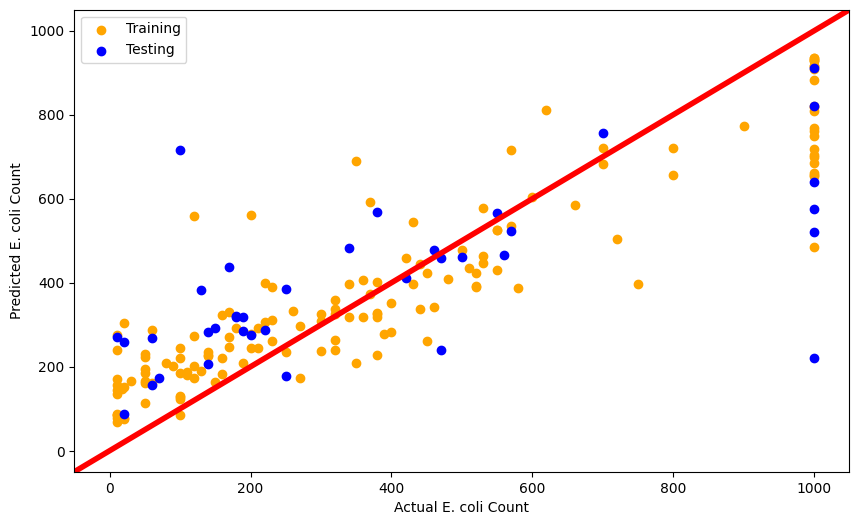

In [209]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_train, best_model.predict(X_train), color = 'orange')
ax.scatter(y_test, y_pred, color = 'blue')
ax.set_xlabel('Actual E. coli Count')
ax.set_ylabel('Predicted E. coli Count')

ax.legend(['Training', 'Testing', 'Predicted'])

ax.axline((0, 0), (1000, 1000), linewidth=4, color='r')

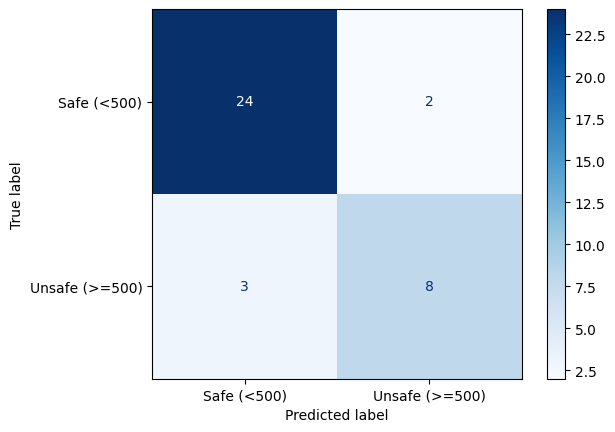

In [210]:
# use 500 threshold = excellent to get confusion matrix
# EC: ≤500 cfu/100ml

y_test_class = (y_test >= 500).astype(int)
y_pred_class = (y_pred >= 500).astype(int)

cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (<500)', 'Unsafe (>=500)'])
disp.plot(cmap=plt.cm.Blues)

<Axes: >

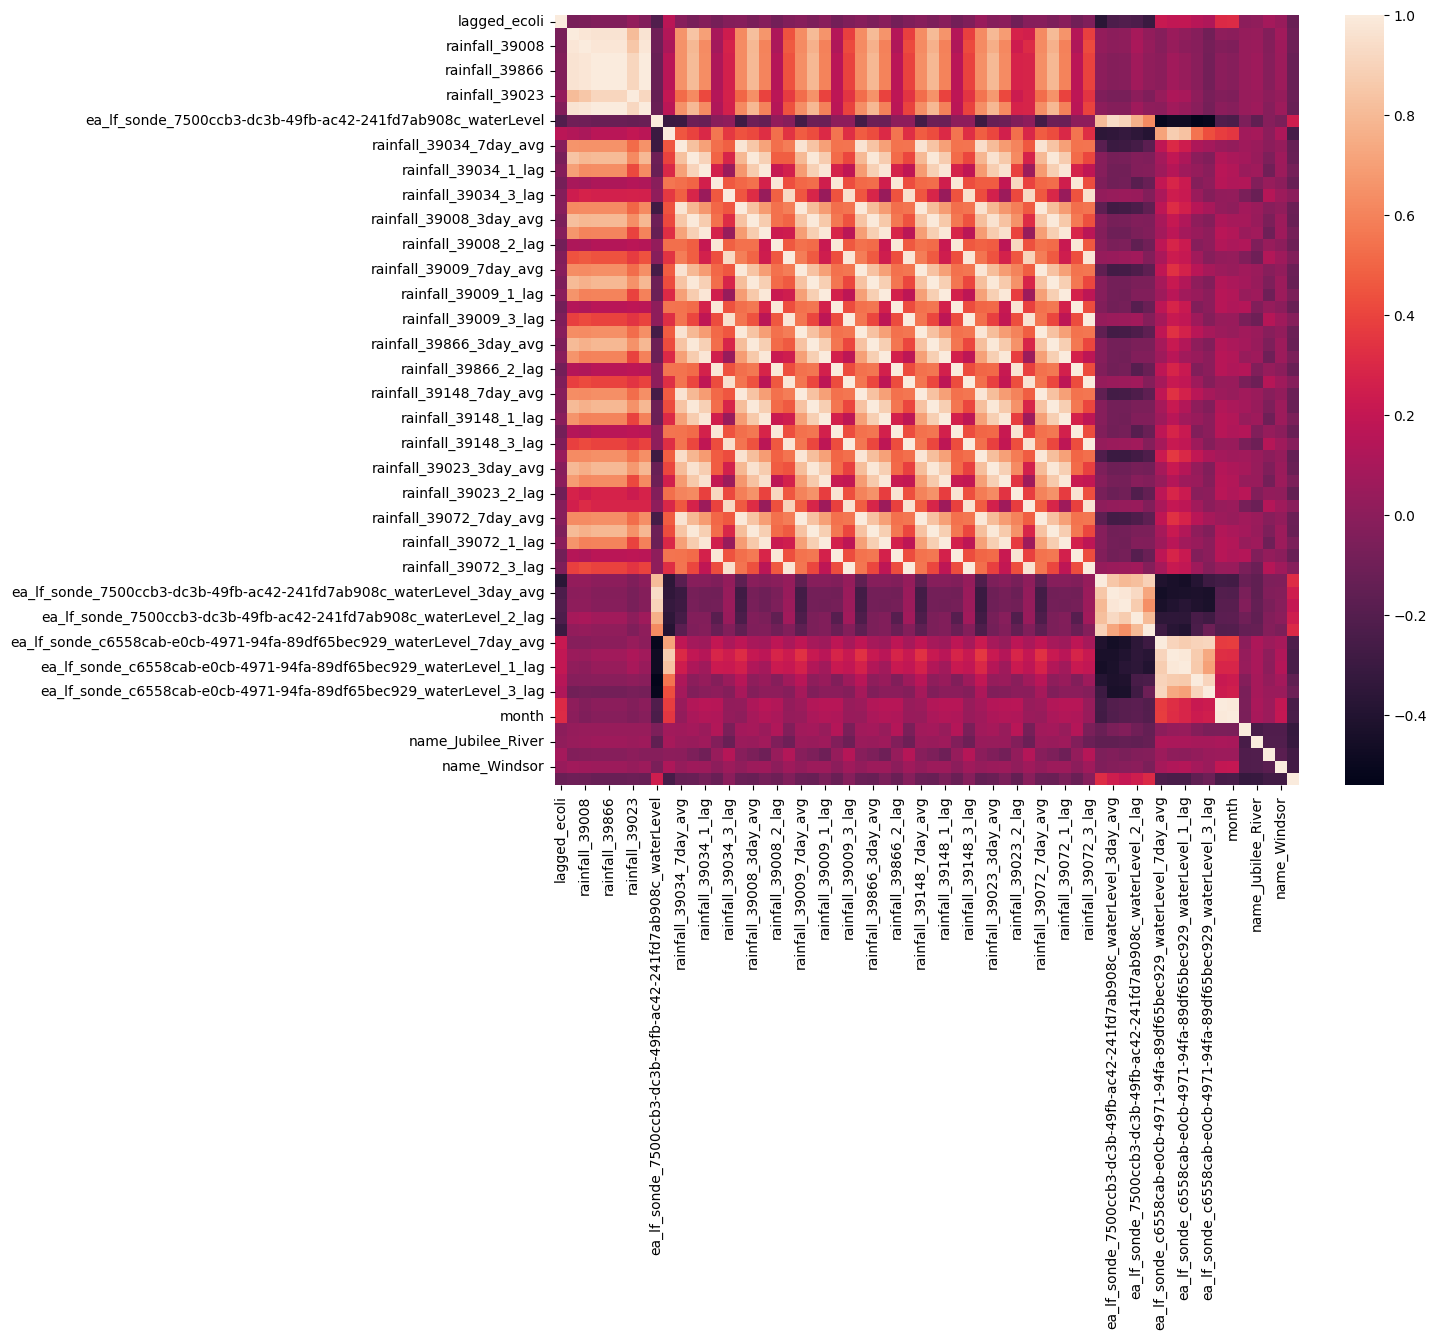

In [254]:
corr = X_train.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, ax=ax)

This shows a lot of the rainfall variables are highly correlated with each other, so including them all won't be improving the model prediction (but also probably not making it worse either, so can just keep)

## Interpret results

<Axes: >

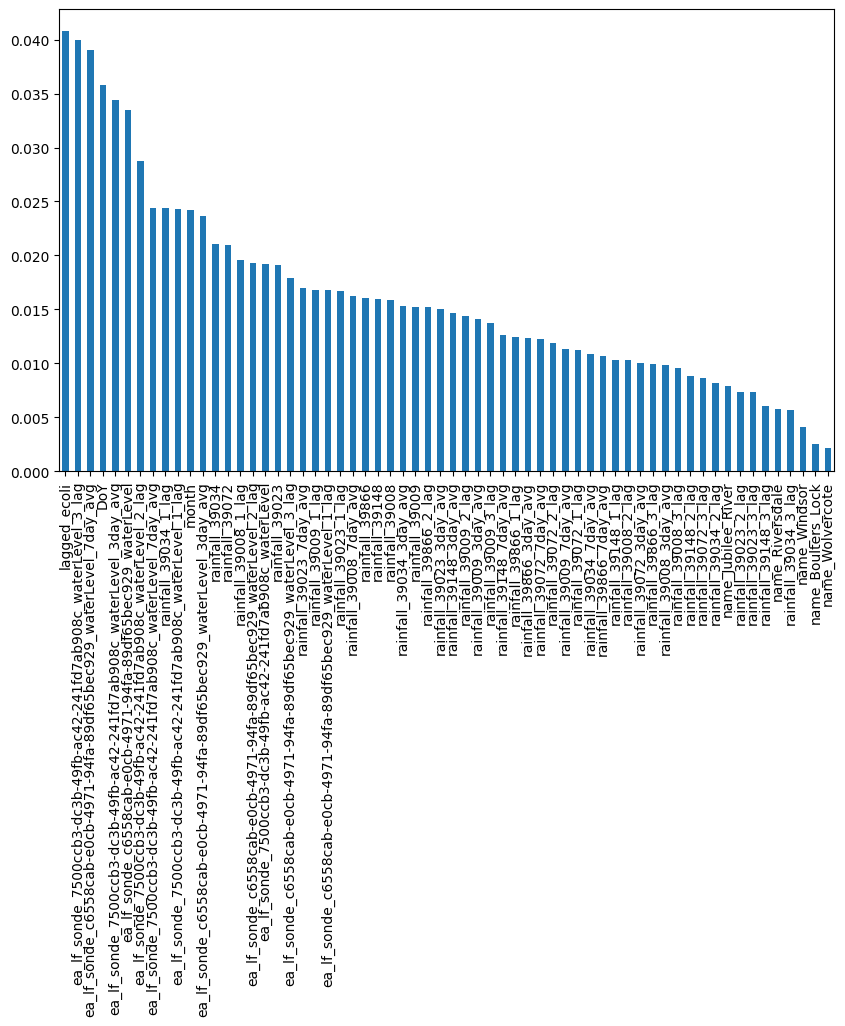

In [211]:
# get feature importances

importances = best_model.feature_importances_
feature_names = X_train.columns
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

#plot feature importances
fig, ax = plt.subplots(figsize=(10, 6))
feature_importances.plot.bar(ax=ax)

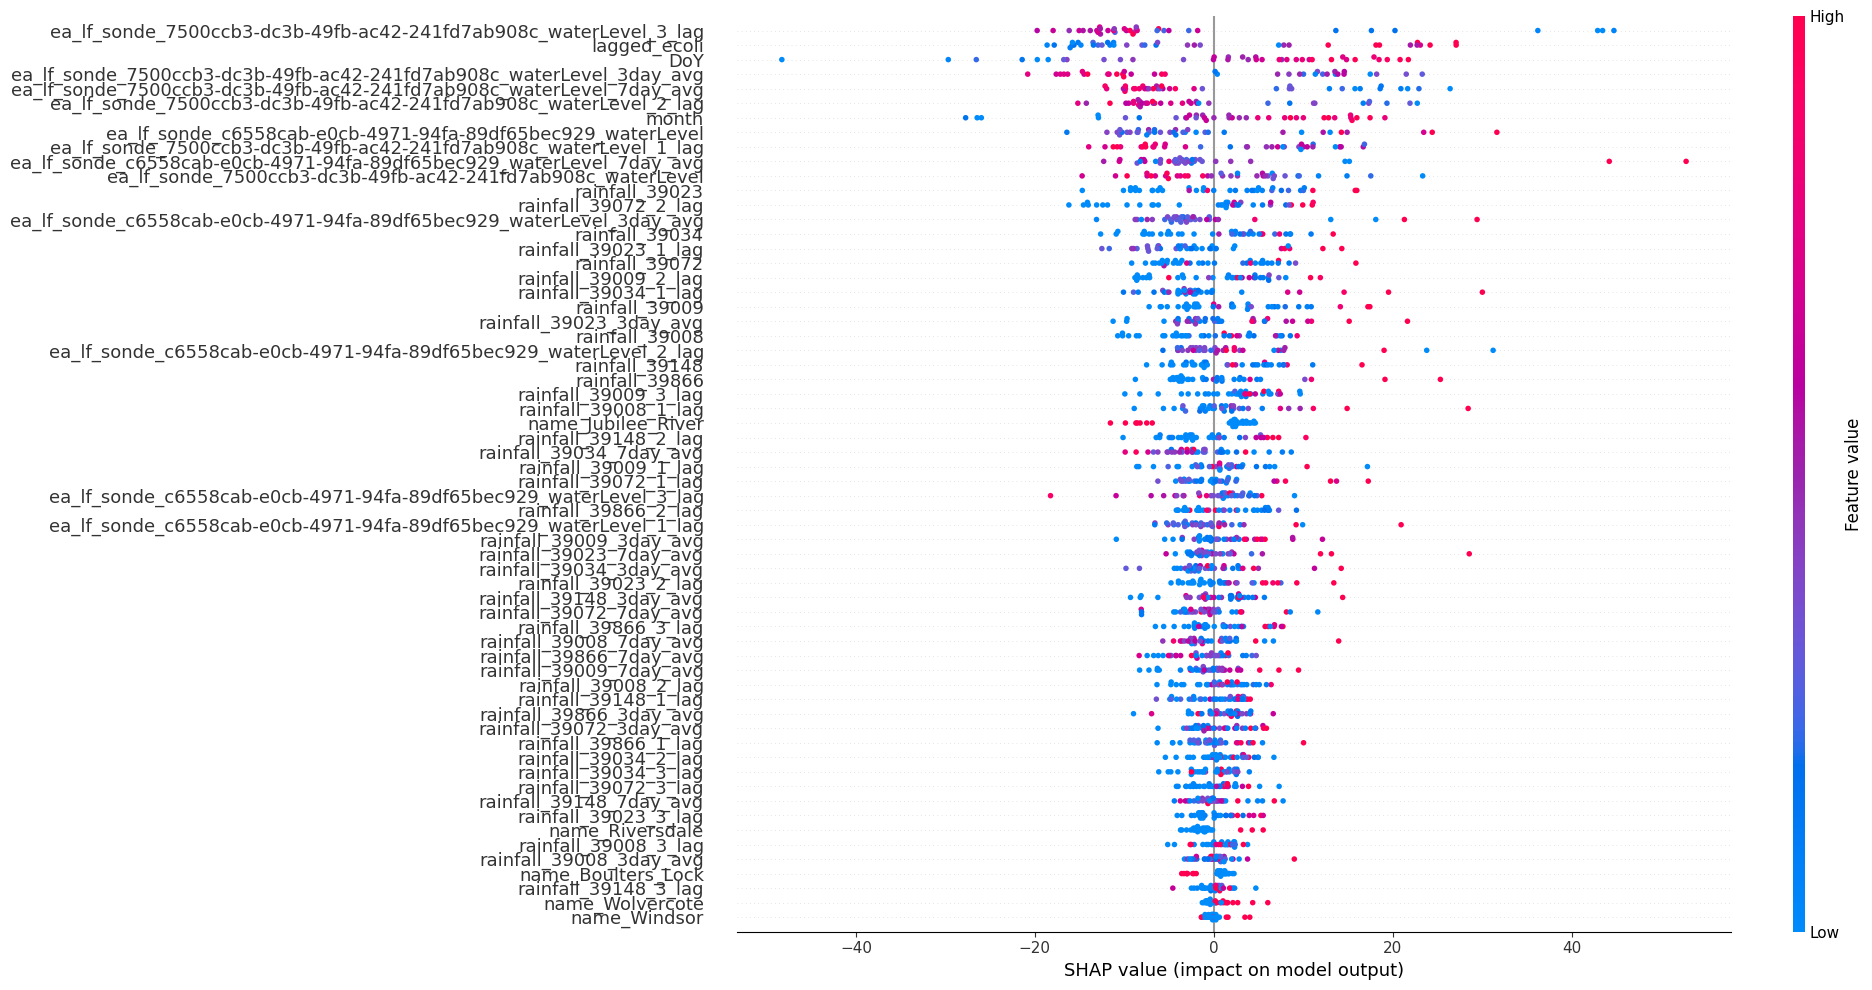

In [212]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_size = (20, 10), max_display = X_test.shape[1])

## Testing LightGBM and XGBoost

LightGBM is worse, XGBoost performs slightly better, but has some errors with fitting

In [213]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, random_state=42)

lgbm_h = LGBMRegressor(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 400, 600],
    "min_child_samples": [5, 10, 20, 30],
    "max_depth": [4, 6, 8, 12, -1],
    "num_leaves": [20, 31, 50, 100],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    lgbm_h,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2218
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 59
[LightGBM] [Info] Start training from score 390.189189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [214]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Mean Absolute Error, MAE = %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error, MSE = %.2f" % mean_squared_error(y_test, y_pred))
print("Max Error = %.2f" % max_error(y_test, y_pred))
print("Explained Variance Score = %.2f" % explained_variance_score(y_test, y_pred))
print("Coefficient of determination, r2 = %.2f" % r2_score(y_test, y_pred)) #usually use this one

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2218
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 59
[LightGBM] [Info] Start training from score 390.189189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

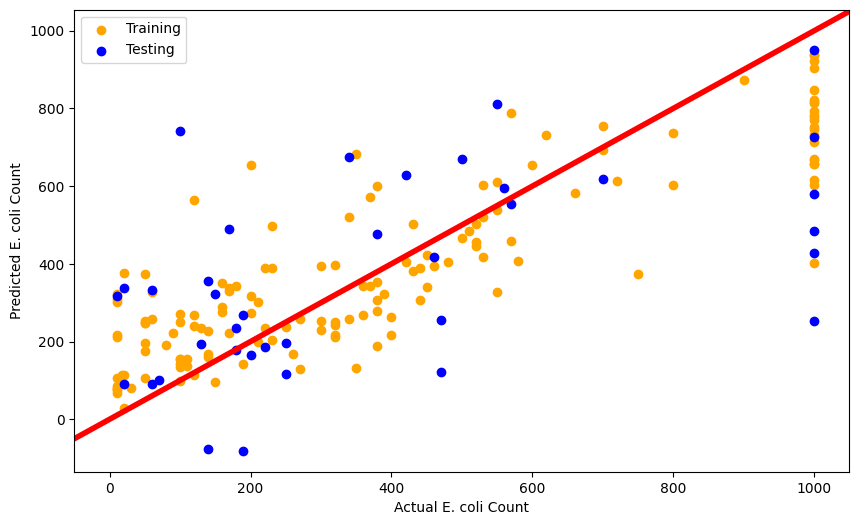

In [215]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_train, best_model.predict(X_train), color = 'orange')
ax.scatter(y_test, y_pred, color = 'blue')
ax.set_xlabel('Actual E. coli Count')
ax.set_ylabel('Predicted E. coli Count')

ax.legend(['Training', 'Testing', 'Predicted'])

ax.axline((0, 0), (1000, 1000), linewidth=4, color='r')

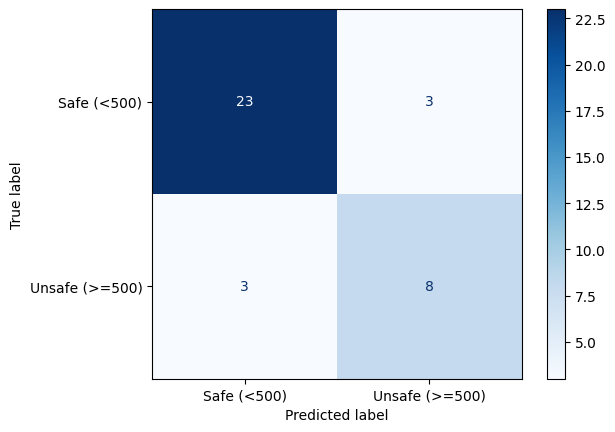

In [216]:
# use 500 threshold = excellent to get confusion matrix
# EC: ≤500 cfu/100ml

y_test_class = (y_test >= 500).astype(int)
y_pred_class = (y_pred >= 500).astype(int)

cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (<500)', 'Unsafe (>=500)'])
disp.plot(cmap=plt.cm.Blues)

In [217]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_h = XGBRegressor(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 400, 600],
    "max_depth": [4, 6, 8, 12, -1],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_h,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)

c:\Users\seana\.virtualenvs\swimming-safety-prediction-fsU5DlmV\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
65 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
65 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\seana\.virtualenvs\swimming-safety-prediction-fsU5DlmV\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\seana\.virtualenvs\swimming-safety-prediction-fsU5DlmV\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\seana\.virtualenvs\swimming-safet

{'subsample': 0.6, 'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [218]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Mean Absolute Error, MAE = %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error, MSE = %.2f" % mean_squared_error(y_test, y_pred))
print("Max Error = %.2f" % max_error(y_test, y_pred))
print("Explained Variance Score = %.2f" % explained_variance_score(y_test, y_pred))
print("Coefficient of determination, r2 = %.2f" % r2_score(y_test, y_pred)) #usually use this one

Mean Absolute Error, MAE = 171.94
Mean squared error, MSE = 54448.14
Max Error = 700.66
Explained Variance Score = 0.48
Coefficient of determination, r2 = 0.48


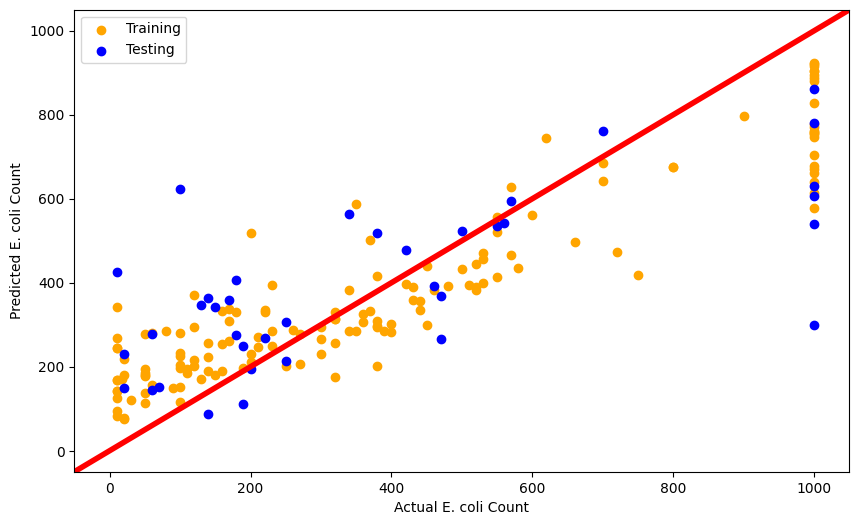

In [219]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_train, best_model.predict(X_train), color = 'orange')
ax.scatter(y_test, y_pred, color = 'blue')
ax.set_xlabel('Actual E. coli Count')
ax.set_ylabel('Predicted E. coli Count')

ax.legend(['Training', 'Testing', 'Predicted'])

ax.axline((0, 0), (1000, 1000), linewidth=4, color='r')

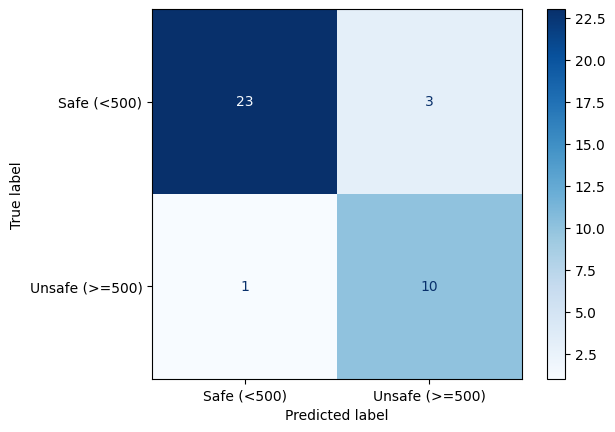

In [220]:
# use 500 threshold = excellent to get confusion matrix
# EC: ≤500 cfu/100ml

y_test_class = (y_test >= 500).astype(int)
y_pred_class = (y_pred >= 500).astype(int)

cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (<500)', 'Unsafe (>=500)'])
disp.plot(cmap=plt.cm.Blues)

## Classification

Now, instead of trying to predict e-coli value, just predict binary (> 500 or < 500)

In [222]:
df_target_predictors['target_ecoli'] = [True if val >= 500 else False for val in df_target_predictors['target_ecoli']]
df_target_predictors['lagged_ecoli'] = [True if val >= 500 else False for val in df_target_predictors['lagged_ecoli']]
df_target_predictors

,target_ecoli,lagged_ecoli,rainfall_39034,rainfall_39008,rainfall_39009,rainfall_39866,rainfall_39148,rainfall_39023,rainfall_39072,ea_lf_sonde_7500ccb3-dc3b-49fb-ac42-241fd7ab908c_waterLevel,...,ea_lf_sonde_c6558cab-e0cb-4971-94fa-89df65bec929_waterLevel_1_lag,ea_lf_sonde_c6558cab-e0cb-4971-94fa-89df65bec929_waterLevel_2_lag,ea_lf_sonde_c6558cab-e0cb-4971-94fa-89df65bec929_waterLevel_3_lag,DoY,month,name_Boulters_Lock,name_Jubilee_River,name_Riversdale,name_Windsor,name_Wolvercote
0,False,False,3.428,2.649,2.059,2.059,2.059,0.994,2.032,0.195439,...,0.196704,0.135735,0.131755,137,5,0.0,0.0,0.0,0.0,1.0
1,False,False,0.207,0.170,0.397,0.397,0.397,0.245,0.408,0.059763,...,0.187111,0.208474,0.216404,145,5,0.0,0.0,0.0,0.0,1.0
2,False,False,0.000,0.001,0.006,0.006,0.006,0.000,0.005,0.095235,...,0.156670,0.157673,0.151596,153,6,0.0,0.0,0.0,0.0,1.0
3,False,False,0.004,0.015,0.005,0.005,0.005,0.000,0.005,0.072469,...,0.168122,0.209469,0.209536,161,6,0.0,0.0,0.0,0.0,1.0
4,False,False,0.112,0.534,1.092,1.093,1.092,0.736,1.073,0.131030,...,0.136717,0.113704,0.143837,170,6,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,True,True,6.802,4.230,4.267,4.268,4.268,4.712,4.228,0.081173,...,0.153031,0.156701,0.129677,324,11,0.0,0.0,0.0,1.0,0.0
181,True,True,9.618,6.709,10.523,10.518,10.520,13.793,10.749,0.064619,...,0.366247,0.125556,0.092837,331,11,0.0,0.0,0.0,1.0,0.0
182,False,True,0.110,0.068,0.077,0.077,0.077,0.035,0.078,-0.159041,...,0.448306,0.525980,0.581041,338,12,0.0,0.0,0.0,1.0,0.0
183,False,False,0.000,0.003,0.011,0.011,0.011,0.000,0.011,-0.182143,...,0.295898,0.274827,0.221735,345,12,0.0,0.0,0.0,1.0,0.0


In [223]:
X = df_target_predictors.drop(columns=['target_ecoli'])
y = df_target_predictors['target_ecoli']

In [246]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 400, 600],
    "max_depth": [4, 6, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)

best_model_rf = search.best_estimator_
best_model_rf.fit(X_train, y_train)

y_pred = best_model_rf.predict(X_test)

{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 6}


In [247]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(best_model_rf,X_train,y_train,cv=5,scoring='r2' ) #cross_val_score does the same as above, but in one line
print("Cross-validated r2:")
print(score)
print("mean r2 =", np.mean(score)) 
print("sd =", np.std(score))

Cross-validated r2:
[ 0.36507937 -0.2        -0.5        -0.45        0.19444444]
mean r2 = -0.11809523809523799
sd = 0.344632894099854


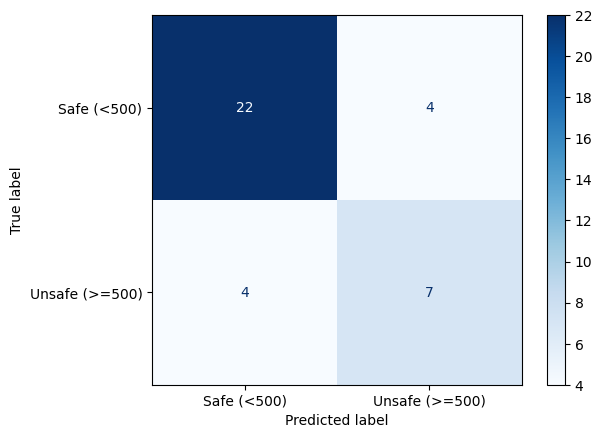

In [248]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (<500)', 'Unsafe (>=500)'])
disp.plot(cmap=plt.cm.Blues)

In [236]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from lightgbm import LGBMClassifier

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, random_state=42)

lgbm_h = LGBMClassifier(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 400, 600],
    "min_child_samples": [5, 10, 20, 30],
    "max_depth": [4, 6, 8, 12, -1],
    "num_leaves": [20, 31, 50, 100],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    lgbm_h,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)

best_model_lgbm = search.best_estimator_
best_model_lgbm.fit(X_train, y_train)

y_pred = best_model_lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 47, number of negative: 101
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2188
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.317568 -> initscore=-0.764973
[LightGBM] [Info] Start training from score -0.764973
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [237]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(best_model_lgbm,X_train,y_train,cv=5,scoring='r2' ) #cross_val_score does the same as above, but in one line
print("Cross-validated r2:")
print(score)
print("mean r2 =", np.mean(score)) 
print("sd =", np.std(score))

[LightGBM] [Info] Number of positive: 38, number of negative: 80
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846
[LightGBM] [Info] Number of data points in the train set: 118, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.322034 -> initscore=-0.744440
[LightGBM] [Info] Start training from score -0.744440
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

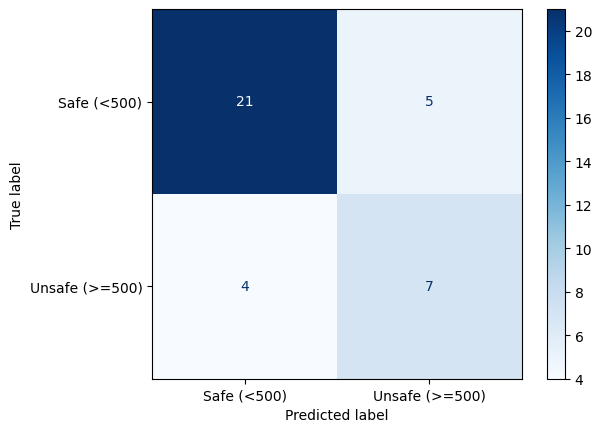

In [238]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (<500)', 'Unsafe (>=500)'])
disp.plot(cmap=plt.cm.Blues)

In [242]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_h = XGBClassifier(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 400, 600],
    "max_depth": [4, 6, 8, 12, -1],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_h,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_params_)


best_model_xgb = search.best_estimator_
best_model_xgb.fit(X_train, y_train)

y_pred = best_model_xgb.predict(X_test)

c:\Users\seana\.virtualenvs\swimming-safety-prediction-fsU5DlmV\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
65 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
65 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\seana\.virtualenvs\swimming-safety-prediction-fsU5DlmV\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\seana\.virtualenvs\swimming-safety-prediction-fsU5DlmV\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\seana\.virtualenvs\swimming-safet

{'subsample': 0.6, 'n_estimators': 50, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


In [243]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(best_model_xgb,X_train,y_train,cv=5,scoring='r2' ) #cross_val_score does the same as above, but in one line
print("Cross-validated r2:")
print(score)
print("mean r2 =", np.mean(score)) 
print("sd =", np.std(score))

Cross-validated r2:
[-0.58730159 -0.05       -0.35       -0.61111111 -0.12777778]
mean r2 = -0.3452380952380952
sd = 0.22967820664839203


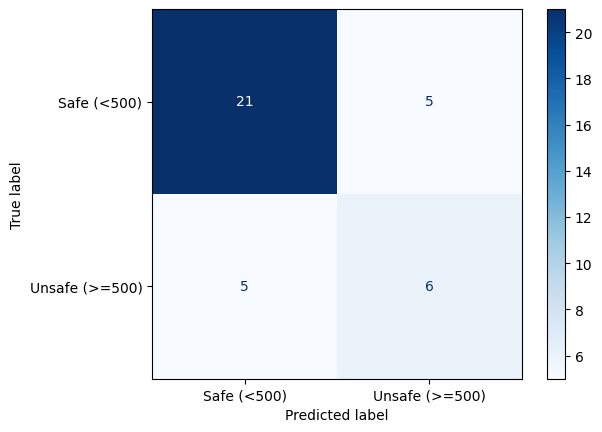

In [244]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (<500)', 'Unsafe (>=500)'])
disp.plot(cmap=plt.cm.Blues)

AUC Random Forest = 0.8286713286713286
AUC LightGBM = 0.8216783216783217
AUC XGBoost = 0.8181818181818181


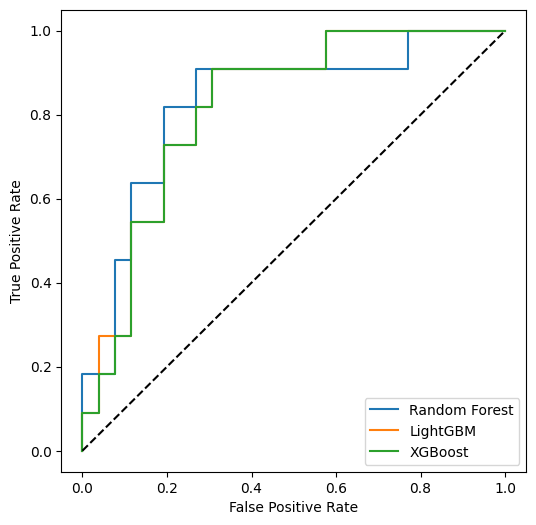

In [252]:
from sklearn.metrics import roc_curve

probs_rf = best_model_rf.predict_proba(X_test) #extracting probabilities of each prediction being 1 or 0
fpr_rf,tpr_rf,thresholds = roc_curve(y_test,probs_rf[:,1]) #so can then move threshold to get different fpr and tpr

probs_lgbm = best_model_lgbm.predict_proba(X_test) #extracting probabilities of each prediction being 1 or 0
fpr_lgbm,tpr_lgbm,thresholds = roc_curve(y_test,probs_lgbm[:,1]) #so can then move threshold to get different fpr and tpr

probs_xgb = best_model_xgb.predict_proba(X_test) #extracting probabilities of each prediction being 1 or 0
fpr_xgb,tpr_xgb,thresholds = roc_curve(y_test,probs_xgb[:,1]) #so can then move threshold to get different fpr and tpr

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_rf,tpr_rf,label="Random Forest")
ax.plot(fpr_lgbm,tpr_lgbm,label="LightGBM")
ax.plot(fpr_xgb,tpr_xgb,label="XGBoost")
ax.plot([0,1],[0,1],'k--') #diagonal line
ax.legend()
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

from sklearn.metrics import roc_auc_score
print('AUC Random Forest =',roc_auc_score(y_test,probs_rf[:,1]))
print('AUC LightGBM =',roc_auc_score(y_test,probs_lgbm[:,1]))
print('AUC XGBoost =',roc_auc_score(y_test,probs_xgb[:,1]))

A higher AUC = better (ie. more true positives, less false positives). Here, all models perform very similarly